# Error Correction Model Parameter Estimation

The Error Correction for two $I(1)$ processes, $X_t$ and $Y_t$ the ECM is given by,

$
\begin{align}
\Delta Y_t = \gamma \Delta X_t + \lambda \left( Y_{t-1} - \beta X_{t-1} \right) + \nu_t
\end{align}
\tag{1}
$

where $\nu_t \sim \text{Normal}(0, \sigma^2)$.</br>

To perform parameter estimation let,

$
\begin{align}
\varepsilon_{t-1} = Y_{t-1} - \beta X_{t-1}
\end{align}
\tag{2}
$

OLS is used to used to estimate $\beta$ to obtain,

$
\begin{align}
\hat{\varepsilon}_{t-1} = Y_{t-1} - \hat{\beta} X_{t-1}
\end{align}
\tag{3}
$

where $\hat{\beta}$ is the OLS estimate of $\beta$. Next the ADF test is used to test $\hat{\varepsilon}_{t-1}$ for stationarity. Replacing the $Y_{t-1} - \beta X_{t-1}$ term in the ECM with $\hat{\varepsilon}_{t-1}$ gives

$
\begin{align}
\Delta Y_t = \gamma \Delta X_t - \lambda \hat{\varepsilon}_{t-1} + \nu_t
\end{align}
\tag{4}
$

Next $\gamma$ and $\lambda$ can be estimated using OLS. This is called the Granger two-step process.

In [20]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
import numpy
from matplotlib import pyplot
import statsmodels.api as sm

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import ecm, stats, adf, arima
from lib.plots import comparison, ecm_beta
from lib.utils import create_ensemble

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [21]:
def ecm_comparison_plot(xt, yt, φ, β, γ, λ, σ=1.0):
    title = f"ECM Simulation: φ={φ}, β={β}, γ={γ}, λ={λ}, σ={σ}"
    εt = yt - β * xt
    labels = [r"$x_t$", r"$y_t$", r"$\hat{\varepsilon}=y_t - \hat{\beta}x_t$"]
    comparison([xt, yt, εt], title=title, ylabel=r"$S_t$", xlabel=r"$t$", labels=labels, lw=1)

## Simulation Parameters

In [22]:
φ = 0.5
β = 0.5
λ = -0.25
γ = 0.75
npts = 1000

### $\beta$ Estimation

In [23]:
t, [xt, yt] = ecm.create_source(φ=φ, β=β, λ=λ, γ=γ, npts=npts)

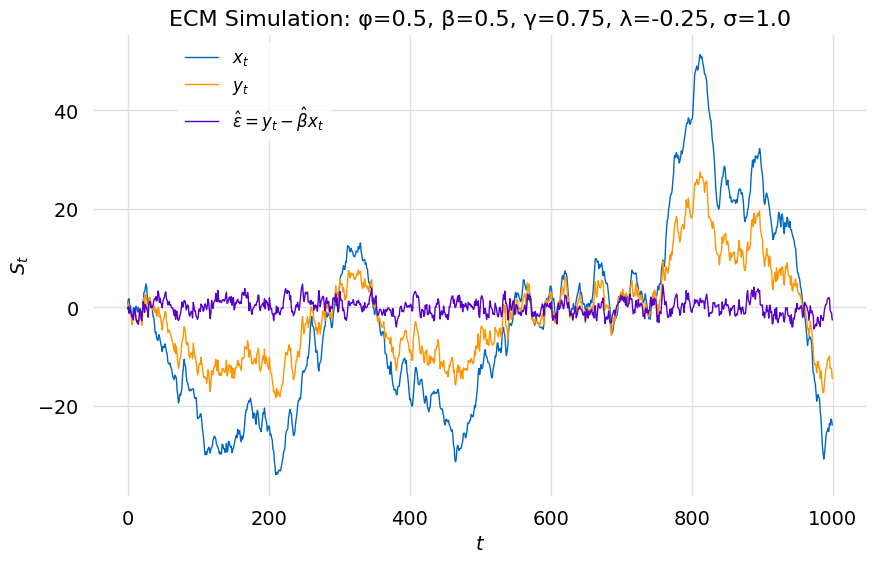

In [24]:
ecm_comparison_plot(xt, yt, φ, β, γ, λ)

#### Residual Stationarity

In [25]:
εt = yt - β * xt
result, result_model = adf.compute_adf_test(εt)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -11.4871      │
├────────────────┼───────────────┤
│ pvalue         │   7.26731e-21 │
├────────────────┼───────────────┤
│ Lags           │   0           │
├────────────────┼───────────────┤
│ Number Obs     │ 999           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56798 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


In [26]:
print(result_model.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "STATIONARITY",
    "test_data": [
        {
            "status": "FAILED",
            "stat": {
                "label": "$t$",
                "value": -11.487059496780551,
                "hyp_test_id": "606ca937-4a55-441f-a809-d6119b9f23fc"
            },
            "pval": {
                "label": "$p-value$",
                "value": 7.267308745193359e-21,
                "hyp_test_id": "606ca937-4a55-441f-a809-d6119b9f23fc"
            },
            "params": [],
            "sig": {
                "label": "1%",
                "value": 0.01,
                "hyp_test_id": "606ca937-4a55-441f-a809-d6119b9f23fc"
            },
            "lower": {
                "label": "$t_L$",
                "value": -2.5679816723029334,
                "hyp_test_id": "606ca937-4a55-441f-a809-d6119b9f23fc"
            },
            "upper": null,
            "hyp_test_id": "606ca937-4a55-441f-a809-d6119b9

In [34]:
result, beta_result_model = ecm.compute_beta_estimate(yt, xt)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.973
Model:                            OLS   Adj. R-squared:                  0.973
Method:                 Least Squares   F-statistic:                 3.591e+04
Date:                Sat, 30 Sep 2023   Prob (F-statistic):               0.00
Time:                        18:56:26   Log-Likelihood:                -1854.7
No. Observations:                1000   AIC:                             3713.
Df Residuals:                     998   BIC:                             3723.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0316      0.049      0.639      0.523      -0.065       0.129
x1             0.5004      0.003    189.507      0.000       0.495       0.506
==============================================================================
Omnibus:                        2.968   Durbin-Watson:                   0.471
Prob(Omnibus):                  0.227   Jarque-Bera (JB):                2.774
Skew:                           0.073   Prob(JB):                        0.250
Kurtosis:                       2.787   Cond. No.                         18.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [35]:
print(beta_result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": 0.03160787514251422,
      "err": 0.049427271648543165,
      "est_label": null,
      "err_label": null,
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "8ac1bec7-cfaa-461a-b61f-2badb31b67e8",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": 0.5003987016363733,
         "err": 0.0026405260004688587,
         "est_label": null,
         "err_label": null,
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "8ac1bec7-cfaa-461a-b61f-2badb31b67e8",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": 0.9729619755010146,
   "param_transforms": [
      {
         "param": {
            "est": 0.5003987016363733,
            "err": 0.0026405260004688587,
            "est_label": "$\\hat{\\beta}$",
            "err_label": "$\\sigma_{\\hat{\\beta}}$",
            "row": 0,
            "column": 0,
            "order": 1,
            "est_id": "8ac1bec7-cfaa-46

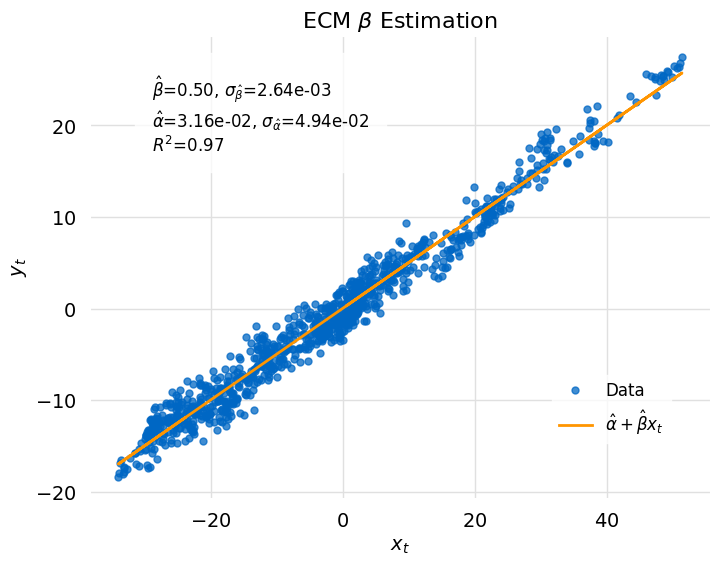

In [32]:
ecm_beta(yt, result_model, xt)

### $\gamma$ and $\lambda$ Estimation

In [37]:
result, result_model = ecm.compute_gamma_lambda_estimate(yt, xt, beta_result_model.params[0].est)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.430
Model:                            OLS   Adj. R-squared:                  0.429
Method:                 Least Squares   F-statistic:                     375.2
Date:                Sat, 30 Sep 2023   Prob (F-statistic):          3.46e-122
Time:                        18:56:41   Log-Likelihood:                -1400.9
No. Observations:                 999   AIC:                             2808.
Df Residuals:                     996   BIC:                             2823.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0053      0.031     -0.171      0.864      -0.067       0.056
x1             0.6499      0.029     22.460      0.000       0.593       0.707
x2             0.2133      0.021     10.327      0.000       0.173       0.254
==============================================================================
Omnibus:                        2.468   Durbin-Watson:                   2.024
Prob(Omnibus):                  0.291   Jarque-Bera (JB):                2.342
Skew:                          -0.090   Prob(JB):                        0.310
Kurtosis:                       3.155   Cond. No.                         1.59
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""